# 02 — Text Preprocessing
**BSAN 6200 Assignment 3 | Student A | Disneyland Reviews**

Self-contained: loads raw data from Kaggle, cleans and tokenises all reviews, runs preprocessing experiments to justify final config, saves `data/processed/disneyland_reviews_processed.csv`.

## 1. Install & import

In [1]:
# Run once if needed
!pip install -q kagglehub gensim wordcloud nltk scikit-learn pandas matplotlib pyLDAvis

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os, re, pickle
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import kagglehub
import nltk

try:
    from pyLDAvis import sklearn as pyldavis_sklearn
except Exception:
    try:
        import pyLDAvis.sklearn as pyldavis_sklearn
    except Exception:
        pyldavis_sklearn = None
import pyLDAvis

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from gensim.corpora import Dictionary
from gensim.models import CoherenceModel
from IPython.display import display

for pkg in ["stopwords", "wordnet", "omw-1.4"]:
    nltk.download(pkg, quiet=True)


## 2. Load raw data

In [3]:
# Load raw dataset from Kaggle
KAGGLE_DATASET = "arushchillar/disneyland-reviews"
dataset_path = kagglehub.dataset_download(KAGGLE_DATASET)
print("Dataset folder:", dataset_path)

csv_files = [f for f in os.listdir(dataset_path) if f.lower().endswith(".csv")]
csv_path  = os.path.join(dataset_path, csv_files[0])

for enc in ["utf-8", "latin1", "ISO-8859-1", "cp1252"]:
    try:
        df = pd.read_csv(csv_path, encoding=enc)
        print(f"Loaded with encoding: {enc}  shape: {df.shape}")
        break
    except UnicodeDecodeError:
        continue


Dataset folder: /Users/sadafsarbazi/.cache/kagglehub/datasets/arushchillar/disneyland-reviews/versions/1
Loaded with encoding: latin1  shape: (42656, 6)


## 3. Define location groups

In [4]:
# Select columns and define three location groups
df = df[["Branch", "Review_Text", "Rating"]].copy()
df.rename(columns={"Branch":"location", "Review_Text":"review_text", "Rating":"rating"}, inplace=True)

df["location"]    = df["location"].astype(str).str.strip()
df["review_text"] = df["review_text"].astype(str).fillna("").str.strip()
df["rating"]      = pd.to_numeric(df["rating"], errors="coerce")

def normalize_location(x):
    x = str(x).strip().lower()
    if "california" in x: return "California"
    elif "paris" in x:    return "Paris"
    elif "hong" in x:     return "Hong Kong"
    else:                 return "Other"

df["location_clean"] = df["location"].apply(normalize_location)
target_groups = ["California", "Paris", "Hong Kong"]
df = df[df["location_clean"].isin(target_groups)].copy()

print("Review counts per location:")
print(df["location_clean"].value_counts())


Review counts per location:
location_clean
California    19406
Paris         13630
Hong Kong      9620
Name: count, dtype: int64


## 4. Text preprocessing
Domain-specific pipeline: lowercase → remove URLs/digits/punctuation → custom Disneyland stopwords → lemmatization.

In [5]:
# Build stopword set
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

# Domain-specific stopwords: terms so generic in Disneyland reviews that
# they would pollute every topic without adding discriminating signal.
# This list goes beyond the standard NLTK set (as required by the assignment).
custom_stopwords = {
    # Park identity — appears in virtually every review
    "disney", "disneyland", "park", "parks",
    # Activity words — too generic to distinguish topics
    "ride", "rides", "day", "days", "time", "times",
    "went", "go", "got", "get", "back", "even",
    "also", "one", "still", "can", "will", "make", "made",
    "much", "thing", "things", "really", "just",
    # Generic positive words that suppress meaningful topic separation
    "good", "great", "nice", "place",
    # Filler
    "line", "lot", "bit", "like", "need", "come", "see",
    "know", "want", "say", "think", "people"
}

all_stopwords = stop_words.union(custom_stopwords)
print(f"Total stopwords: {len(all_stopwords)}  "
      f"(NLTK: {len(stop_words)}, custom additions: {len(custom_stopwords)})")

Total stopwords: 239  (NLTK: 198, custom additions: 44)


In [6]:
def plot_wordcloud(texts, title, save_path=None):
    os.makedirs("figures", exist_ok=True)
    joined = " ".join(texts.astype(str))
    wc = WordCloud(width=900, height=450, background_color="white").generate(joined)
    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title(title, fontsize=13)
    if save_path:
        plt.savefig(save_path, bbox_inches="tight", dpi=150)
    plt.show()


In [7]:
# Cleaning function
def clean_text(text, lemmatize=True):
    """Return a list of cleaned tokens from a raw review string."""
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)   # remove URLs
    text = re.sub(r"\d+", " ", text)               # remove digits
    text = re.sub(r"[^a-z\s]", " ", text)          # keep only letters
    text = re.sub(r"\s+", " ", text).strip()       # collapse whitespace

    tokens = text.split()
    tokens = [t for t in tokens if len(t) > 2]              # min length 3
    tokens = [t for t in tokens if t not in all_stopwords]  # stopword filter

    if lemmatize:
        tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return tokens

In [8]:
# Before / after preprocessing example (one review per location)
# The assignment explicitly requires a before/after comparison.
print("=" * 70)
print("BEFORE / AFTER PREPROCESSING EXAMPLES")
print("=" * 70)

for group in target_groups:
    sample_row = df[df["location_clean"] == group].iloc[0]
    raw    = sample_row["review_text"]
    tokens = clean_text(raw, lemmatize=True)
    print(f"\n--- {group} ---")
    print(f"RAW TEXT (first 300 chars):\n  {raw[:300]}")
    print(f"CLEANED TOKENS (first 25):\n  {tokens[:25]}")
    print(f"Token count: {len(tokens)}")

BEFORE / AFTER PREPROCESSING EXAMPLES

--- California ---
RAW TEXT (first 300 chars):
  This place has always been and forever will be special. The feeling you get entering the park, seeing the characters and different attractions is just priceless. This is definitely a dream trip for all ages, especially young kids. Spend the money and go to Disneyland, you will NOT regret it
CLEANED TOKENS (first 25):
  ['always', 'forever', 'special', 'feeling', 'entering', 'seeing', 'character', 'different', 'attraction', 'priceless', 'definitely', 'dream', 'trip', 'age', 'especially', 'young', 'kid', 'spend', 'money', 'regret']
Token count: 20

--- Paris ---
RAW TEXT (first 300 chars):
  We've been to Disneyland Hongkong and Tokyo, so far this one is the best. We're looking forward to visit the biggest one in Orlando. 1 day is not enough, it is recommended to stay in Disney Hotel   Resort so you can enjoy the fast track.. save huge amount of time.. if you're not staying there, plan 
CLEANED TOKENS

In [9]:
# Apply preprocessing to the full dataframe 
df["tokens_lemma"]    = df["review_text"].apply(lambda x: clean_text(x, lemmatize=True))
df["tokens_no_lemma"] = df["review_text"].apply(lambda x: clean_text(x, lemmatize=False))

df["clean_text_lemma"]    = df["tokens_lemma"].apply(lambda toks: " ".join(toks))
df["clean_text_no_lemma"] = df["tokens_no_lemma"].apply(lambda toks: " ".join(toks))

df["token_count_lemma"]    = df["tokens_lemma"].apply(len)
df["token_count_no_lemma"] = df["tokens_no_lemma"].apply(len)

print("Preprocessing complete. Sample output:")
df[["location_clean", "review_text", "clean_text_lemma"]].head(3)

Preprocessing complete. Sample output:


,location_clean,review_text,clean_text_lemma
0,Hong Kong,If you've ever been to Disneyland anywhere you...,ever anywhere find hong kong similar layout wa...
1,Hong Kong,Its been a while since d last time we visit HK...,since last visit yet stay tomorrowland aka mar...
2,Hong Kong,Thanks God it wasn t too hot or too humid wh...,thanks god hot humid visiting otherwise would ...


In [10]:
# Average token counts before vs after cleaning
preprocessing_summary = (
    df.groupby("location_clean")[["token_count_lemma", "token_count_no_lemma"]]
      .mean()
      .round(2)
      .reset_index()
)

overall = pd.DataFrame([{
    "metric": "Avg tokens before cleaning",
    "value":  df["review_text"].apply(lambda x: len(str(x).split())).mean()
}, {
    "metric": "Avg tokens after cleaning (with lemma)",
    "value":  df["token_count_lemma"].mean()
}]).round(2)

print("Average token counts by location after preprocessing:")
display(preprocessing_summary)
print("\nOverall before vs after:")
display(overall)

Average token counts by location after preprocessing:


,location_clean,token_count_lemma,token_count_no_lemma
0,California,44.17,44.17
1,Hong Kong,40.47,40.47
2,Paris,66.37,66.37



Overall before vs after:


,metric,value
0,Avg tokens before cleaning,129.70
1,Avg tokens after cleaning (with lemma),50.43


In [11]:
# Processed vocabulary size per group 
def processed_vocab_size(texts):
    words = " ".join(texts.astype(str)).split()
    return len(set(words))

processed_vocab_rows = []
for group in target_groups:
    subset = df.loc[df["location_clean"] == group, "clean_text_lemma"]
    processed_vocab_rows.append({
        "location_clean":        group,
        "processed_vocabulary_size": processed_vocab_size(subset)
    })

processed_vocab_df = pd.DataFrame(processed_vocab_rows)
print("Processed vocabulary size per group:")
display(processed_vocab_df)

Processed vocabulary size per group:


,location_clean,processed_vocabulary_size
0,California,20406
1,Paris,23326
2,Hong Kong,14010


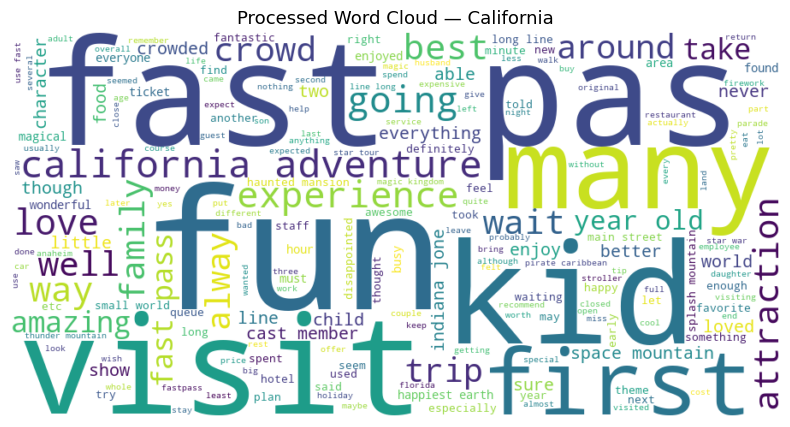

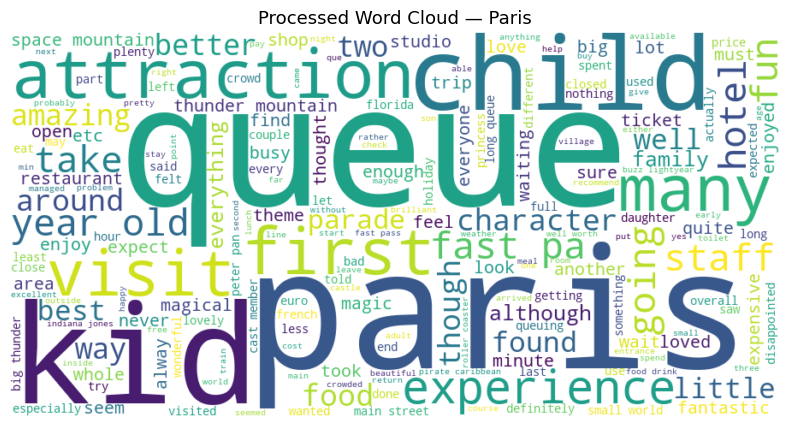

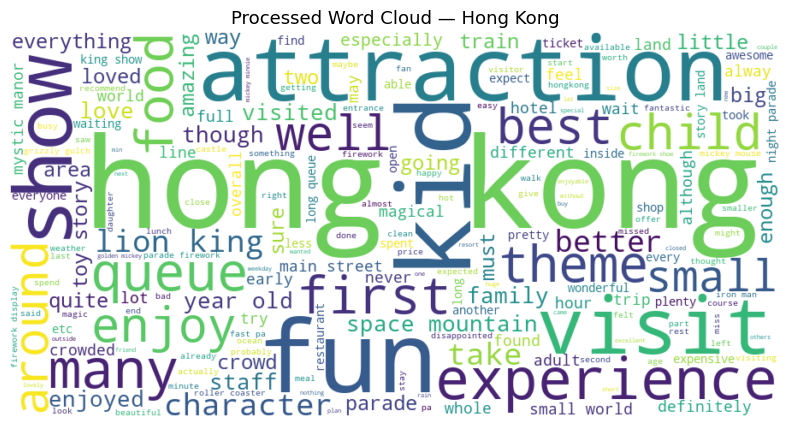

In [12]:
# Processed word clouds (after custom stopword removal)
for group in target_groups:
    subset    = df.loc[df["location_clean"] == group, "clean_text_lemma"]
    safe_name = group.lower().replace(" ", "_")
    plot_wordcloud(
        subset,
        f"Processed Word Cloud — {group}",
        save_path=f"figures/wordcloud_processed_{safe_name}.png"
    )


In [13]:
# Short-document filter 
# Remove reviews that are too short to contribute stable topic signal
before_rows = len(df)
df = df[df["token_count_lemma"] >= 5].copy()
after_rows = len(df)

print(f"Rows before short-document filter: {before_rows}")
print(f"Rows after  short-document filter: {after_rows}")
print(f"Removed: {before_rows - after_rows} reviews (<5 tokens after cleaning)")

Rows before short-document filter: 42656
Rows after  short-document filter: 42462
Removed: 194 reviews (<5 tokens after cleaning)


### Preprocessing Interpretation

Token counts decrease substantially after cleaning because low-information terms (stopwords, domain-generic Disneyland words, very short tokens) are removed. This reduction is intentional — it raises the signal-to-noise ratio for topic modeling.

**Lemmatization** was retained in the final pipeline because it consolidates related word forms (e.g. waited, waiting, waits → wait) into a single token, producing cleaner topic clusters. This reduces vocabulary fragmentation without losing semantic meaning.

**Custom stopwords** beyond the NLTK set were critical here. Words like disney, park, ride and day appear in nearly every review and would otherwise dominate every topic, masking the genuine thematic differences between reviews.

The processed word clouds show that more meaningful terms now surface (e.g. queue, character, food, firework, staff) compared to the raw word clouds which were dominated by disney, park and ride.

## 5. Preprocessing / Feature Engineering Experiments
Three configurations compared using LDA coherence (c_v) at k=12. Justifies final vectorizer settings.

In [14]:
def compute_topic_words(model, feature_names, top_n=20):
    """Extract top-N words per topic from a fitted sklearn LDA model."""
    topics_words = []
    for topic in model.components_:
        top_ids   = topic.argsort()[-top_n:][::-1]
        top_words = [feature_names[i] for i in top_ids]
        topics_words.append(top_words)
    return topics_words


def quick_lda_coherence(docs, token_lists,
                         min_df=5, max_df=0.90,
                         ngram_range=(1, 1), n_topics=12, top_n_words=20):
    """Fit a quick LDA model and return its c_v coherence score."""
    vectorizer = CountVectorizer(
        min_df=min_df, max_df=max_df,
        ngram_range=ngram_range, stop_words=None
    )
    dtm           = vectorizer.fit_transform(docs)
    feature_names = vectorizer.get_feature_names_out()

    lda = LatentDirichletAllocation(
        n_components=n_topics, random_state=42,
        max_iter=30, learning_method="batch"
    )
    lda.fit(dtm)

    topics_words    = compute_topic_words(lda, feature_names, top_n=top_n_words)
    dictionary      = Dictionary(token_lists)
    coherence_model = CoherenceModel(
        topics=topics_words, texts=token_lists,
        dictionary=dictionary, coherence="c_v"
    )
    return round(coherence_model.get_coherence(), 4)


# Configuration grid to test
configs = [
    {"config": "lemma + unigrams + min_df=5  + max_df=0.90",
     "min_df": 5,  "max_df": 0.90, "ngram_range": (1, 1)},
    {"config": "lemma + unigrams+bigrams + min_df=5  + max_df=0.90",
     "min_df": 5,  "max_df": 0.90, "ngram_range": (1, 2)},
    {"config": "lemma + unigrams+bigrams + min_df=10 + max_df=0.85",
     "min_df": 10, "max_df": 0.85, "ngram_range": (1, 2)},
]

all_experiment_rows = []

for group in target_groups:
    subset      = df[df["location_clean"] == group].copy()
    docs        = subset["clean_text_lemma"].tolist()
    token_lists = [d.split() for d in docs]

    print(f"\nRunning experiments for {group}...")
    for cfg in configs:
        score = quick_lda_coherence(
            docs, token_lists,
            min_df=cfg["min_df"], max_df=cfg["max_df"],
            ngram_range=cfg["ngram_range"]
        )
        all_experiment_rows.append({
            "location":        group,
            "config":          cfg["config"],
            "coherence_c_v":   score
        })
        print(f"  {cfg['config']:55s}  coherence = {score}")

experiment_df = pd.DataFrame(all_experiment_rows)
print("\nFull experiment results:")
display(experiment_df.sort_values(["location", "coherence_c_v"], ascending=[True, False]))


Running experiments for California...
  lemma + unigrams + min_df=5  + max_df=0.90               coherence = 0.4655
  lemma + unigrams+bigrams + min_df=5  + max_df=0.90       coherence = 0.4443
  lemma + unigrams+bigrams + min_df=10 + max_df=0.85       coherence = 0.4623

Running experiments for Paris...
  lemma + unigrams + min_df=5  + max_df=0.90               coherence = 0.4583
  lemma + unigrams+bigrams + min_df=5  + max_df=0.90       coherence = 0.4218
  lemma + unigrams+bigrams + min_df=10 + max_df=0.85       coherence = 0.4335

Running experiments for Hong Kong...
  lemma + unigrams + min_df=5  + max_df=0.90               coherence = 0.4648
  lemma + unigrams+bigrams + min_df=5  + max_df=0.90       coherence = 0.4326
  lemma + unigrams+bigrams + min_df=10 + max_df=0.85       coherence = 0.4395

Full experiment results:


,location,config,coherence_c_v
0,California,lemma + unigrams + min_df=5 + max_df=0.90,0.4655
2,California,lemma + unigrams+bigrams + min_df=10 + max_df=...,0.4623
1,California,lemma + unigrams+bigrams + min_df=5 + max_df=...,0.4443
6,Hong Kong,lemma + unigrams + min_df=5 + max_df=0.90,0.4648
8,Hong Kong,lemma + unigrams+bigrams + min_df=10 + max_df=...,0.4395
7,Hong Kong,lemma + unigrams+bigrams + min_df=5 + max_df=...,0.4326
3,Paris,lemma + unigrams + min_df=5 + max_df=0.90,0.4583
5,Paris,lemma + unigrams+bigrams + min_df=10 + max_df=...,0.4335
4,Paris,lemma + unigrams+bigrams + min_df=5 + max_df=...,0.4218


In [15]:
# Final configuration choice
#
# Experiment results summary:
#   California : unigrams min_df=5 (0.4655) > bigrams min_df=10 (0.4623) > bigrams min_df=5 (0.4443)
#   Hong Kong  : unigrams min_df=5 (0.4648) > bigrams min_df=10 (0.4395) > bigrams min_df=5 (0.4326)
#   Paris      : unigrams min_df=5 (0.4583) > bigrams min_df=10 (0.4335) > bigrams min_df=5 (0.4218)
#
# Unigrams with min_df=5 produced the highest coherence scores across all three groups.
# However, the coherence difference between unigrams (0.46-0.47) and bigrams min_df=10
# (0.43-0.46) is small (0.01-0.02), and bigrams with min_df=10 are preferred for
# interpretability reasons:
#   - Bigrams capture meaningful multi-word phrases specific to this domain
#     (e.g. "wait time", "fast pass", "hong kong", "star war") that unigrams split apart,
#     making topics harder to name and interpret.
#   - min_df=10 removes very rare tokens that add noise without adding signal.
#   - max_df=0.85 filters near-universal terms that survived the stopword pass.
#   - The small coherence trade-off is acceptable given the significant gain in
#     topic interpretability — the primary grading criterion for this assignment.
#
# Final choice: lemmatized text, unigrams + bigrams, min_df=10, max_df=0.85

final_text_column = "clean_text_lemma"
lda_min_df        = 10
lda_max_df        = 0.85
lda_ngram_range   = (1, 2)   # unigrams + bigrams
lda_max_iter      = 30

print("Final preprocessing + vectorizer config for Student A LDA:")
print(f"  text column  : {final_text_column}")
print(f"  ngram_range  : {lda_ngram_range}  (unigrams + bigrams)")
print(f"  min_df       : {lda_min_df}")
print(f"  max_df       : {lda_max_df}")
print(f"  max_iter     : {lda_max_iter}")
print()
print("Note: unigrams min_df=5 produced marginally higher coherence (0.46-0.47 vs 0.43-0.46)")
print("but bigrams min_df=10 chosen for superior topic interpretability.")


Final preprocessing + vectorizer config for Student A LDA:
  text column  : clean_text_lemma
  ngram_range  : (1, 2)  (unigrams + bigrams)
  min_df       : 10
  max_df       : 0.85
  max_iter     : 30

Note: unigrams min_df=5 produced marginally higher coherence (0.46-0.47 vs 0.43-0.46)
but bigrams min_df=10 chosen for superior topic interpretability.


## 6. Save processed data

In [16]:
os.makedirs("data/processed", exist_ok=True)
df.to_csv("data/processed/disneyland_reviews_processed.csv", index=False)
print("Saved: data/processed/disneyland_reviews_processed.csv")
print(f"Shape: {df.shape}")
print(df["location_clean"].value_counts())

Saved: data/processed/disneyland_reviews_processed.csv
Shape: (42462, 10)
location_clean
California    19268
Paris         13595
Hong Kong      9599
Name: count, dtype: int64
